In [1]:
import warnings
import numpy as np
import pandas as pd
from hdbscan import HDBSCAN
from itertools import product
from collections import defaultdict

from fast_plscan import PLSCAN
from lib.plotting import plt, sns, configure_matplotlib, sized_fig, fontsize

configure_matplotlib()  # uses latex for text rendering!
data = np.load("data/clusterable/sources/clusterable_data.npy")
warnings.simplefilter(action="ignore", category=FutureWarning)

## PLSCAN


In [3]:
c = PLSCAN(min_samples=5).fit(data)

Layers


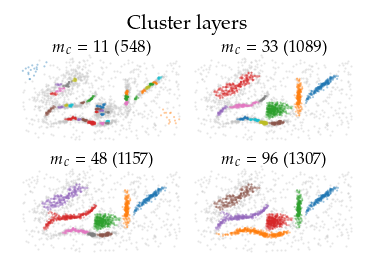

In [4]:
layers = c.cluster_layers(max_peaks=4)

sized_fig(0.32, aspect=0.7)
for i, (size, labels, probs) in enumerate(layers):
    plt.subplot(2, 2, i + 1)
    mask = labels > -1
    plt.scatter(*data[~mask].T, color="silver", s=1, alpha=0.4, linewidth=0)
    plt.scatter(
        *data[mask].T,
        c=labels[mask] % 10,
        s=1,
        alpha=0.4,
        linewidth=0,
        vmax=9,
        cmap="tab10",
    )
    idx = np.searchsorted(c._persistence_trace.min_size, size)
    plt.title(
        f"$m_c={int(size)}$ ({c._persistence_trace.persistence[idx]:.0f})",
        fontsize=fontsize["footnote"],
        y=0.85,
    )
    plt.axis("off")
plt.suptitle("Cluster layers", y=1)
plt.subplots_adjust(left=0, right=1, top=0.85, bottom=0, wspace=0)
plt.savefig("images/plscan_cluster_layers.pdf", pad_inches=0)
plt.show()

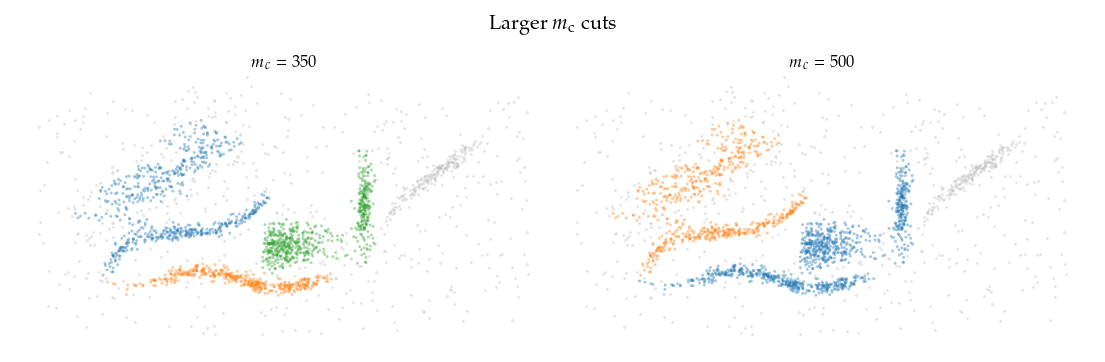

In [5]:
sized_fig(1, 0.618 / 2)
for i, mc in enumerate([350, 500]):
    plt.subplot(1, 2, i + 1)
    labels, probs = c.min_cluster_size_cut(mc)
    mask = labels != -1
    plt.scatter(*data[~mask].T, color="silver", s=2, alpha=0.4, linewidth=0)
    plt.scatter(
        *data[mask].T,
        c=labels[mask] % 10,
        s=2,
        alpha=0.4,
        linewidth=0,
        vmax=9,
        cmap="tab10",
    )
    plt.title(
        f"$m_c={int(mc)}$",
        fontsize=fontsize["footnote"],
        y=0.95,
    )
    plt.axis("off")
plt.suptitle("Larger $m_{\\rm c}$ cuts", y=1)
plt.subplots_adjust(0, 0, 1, 0.85, 0, 0)
plt.savefig("images/plscan_larger_layers.pdf", pad_inches=0)
plt.show()

Leaf tree


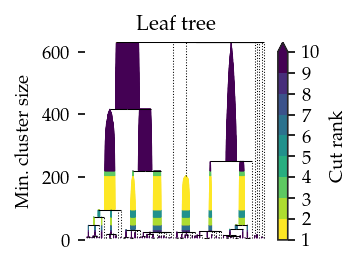

In [6]:
sized_fig(0.32, 0.7)
c.leaf_tree_.plot(leaf_separation=0.05)
plt.title("Leaf tree")
plt.ylabel("Min.~cluster size")
plt.subplots_adjust(0.22, 0.06, 0.88, 0.88)
plt.savefig("images/plscan_leaf_tree.pdf", pad_inches=0)
plt.show()

Persistence trace


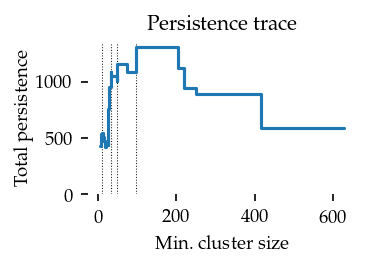

In [7]:
sized_fig(0.32, 0.7)
for size, _, _ in layers:
    plt.axvline(size, color="k", lw=0.5, ls=":", alpha=1)
c.persistence_trace_.plot()
plt.title("Persistence trace")
plt.ylabel("Total persistence", labelpad=1)
plt.xlabel("Min.~cluster size")
plt.subplots_adjust(0.22, 0.25, 1, 0.88)
plt.savefig("images/plscan_persistence_trace.pdf", pad_inches=0)
plt.show()

Parameter sensitivity


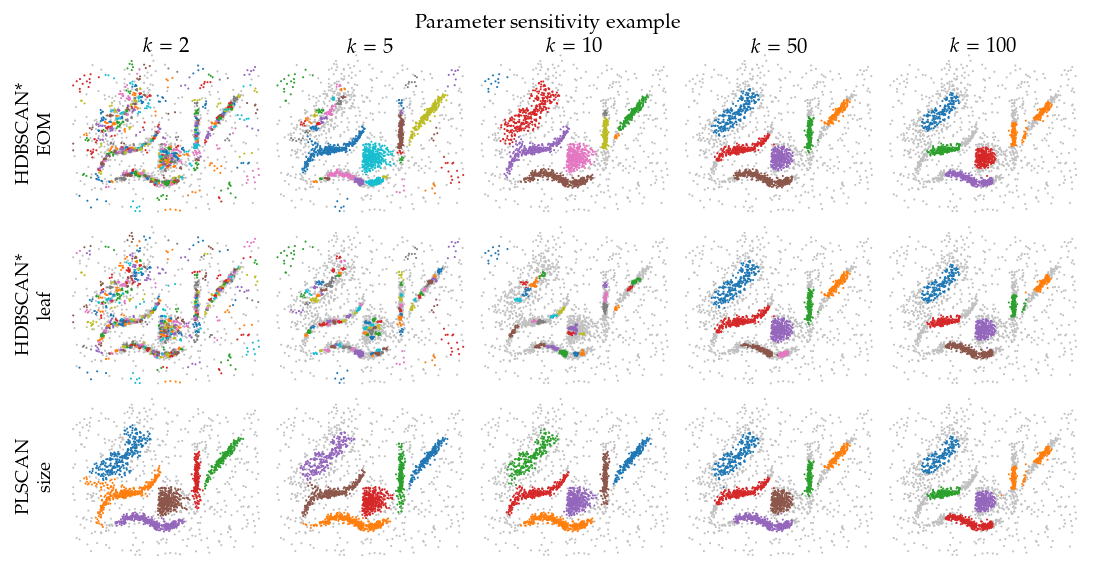

In [8]:
sized_fig(1, 0.85 / 5 * 3)
count = 1
for j, (alg, kwargs, name) in enumerate(
    [
        (HDBSCAN, {}, "HDBSCAN*\nEOM"),
        (HDBSCAN, {"cluster_selection_method": "leaf"}, "HDBSCAN*\nleaf"),
        (PLSCAN, {}, "PLSCAN\nsize"),
    ]
):
    for i, size in enumerate([2, 5, 10, 50, 100]):
        _c = alg(min_samples=size, min_cluster_size=size, **kwargs).fit(data)
        plt.subplot(3, 5, count)
        count += 1
        plot_kwargs = dict(s=1, cmap="tab10", vmax=9, vmin=0, edgecolors="none")
        mask = _c.labels_ == -1
        plt.scatter(*data[mask].T, color="silver", s=1, edgecolors="none")
        plt.scatter(*data[~mask].T, c=_c.labels_[~mask] % 10, **plot_kwargs)
        plt.xticks([])
        plt.yticks([])
        if i == 0:
            plt.ylabel(name)
        if j == 0:
            plt.title(f"$k={size}$", y=0.9)
plt.suptitle("Parameter sensitivity example", y=1)
plt.subplots_adjust(0.05, 0, 1, 0.94, hspace=0, wspace=0)
plt.savefig("images/plscan_parameter_example.pdf", pad_inches=0)
plt.show()

Modelled probability density profile


In [9]:
def pdf_order(tree, current_node, bonus=None):
    children = tree.child[tree.parent == current_node]
    if bonus is not None:
        children = np.concatenate([bonus, children])
    if len(children) == 0:
        return [current_node]
    else:
        sorted_children = np.concatenate([children[0::2], children[1::2][::-1]])
        return sum([pdf_order(tree, child) for child in sorted_children], [])

In [10]:
def density_plot(tree, N, color):
    density_plot_order = np.array(
        pdf_order(tree, N + 1, np.flatnonzero(tree.parent == N))
    )
    density_values = np.empty(density_plot_order.shape[0])
    for idx, i in enumerate(density_plot_order):
        density_values[idx] = np.exp(-100 * tree.distance[tree.child == i][0])
    plt.gca().fill_between(
        np.arange(density_values.shape[0]), density_values, color=color
    )
    return density_plot_order

In [11]:
def label_line(labels, plot_order):
    for idx, i in enumerate(plot_order):
        label = labels[i]
        label_color = f"C{label}" if label != -1 else "silver"
        plt.plot(
            [idx - 0.5, idx + 0.5],
            [-0.04, -0.04],
            color=label_color,
            linewidth=4,
            solid_capstyle="butt",
        )

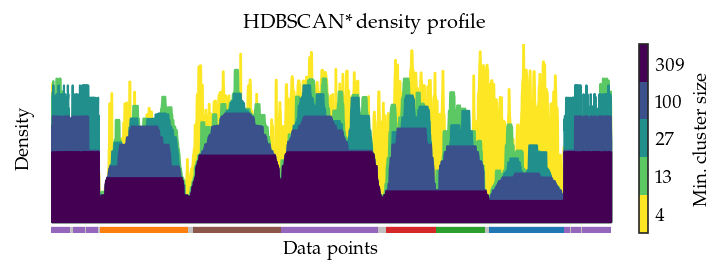

In [12]:
sized_fig(0.66, 0.7 / 2)
mcs = [4, 13, 27, 100, 309]
palette = plt.cm.viridis_r.resampled(len(mcs))
for i, mc in enumerate(mcs):
    c2 = PLSCAN(min_samples=2, min_cluster_size=int(mc)).fit(data)
    plot_order = density_plot(c2._condensed_tree, data.shape[0], palette.colors[i])
    if mc == 100:
        labels, _ = c2.min_cluster_size_cut(mc)
        label_line(labels, plot_order)
plt.ylim(-0.05, 0.8)
plt.xticks([])
plt.yticks([])
plt.ylabel("Density", labelpad=-5)
plt.xlabel("Data points")
plt.suptitle("HDBSCAN* density profile", y=1, va="top")
cb = plt.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(0, len(mcs)), cmap=palette),
    ax=plt.gca(),
    label="Min.~cluster size",
    ticks=[i + 0.5 for i in range(len(mcs))],
    pad=0,
)
cb.ax.tick_params(length=0)
cb.set_ticklabels([str(int(mc)) for mc in mcs])
plt.subplots_adjust(0.020, 0.12, 1.04, 0.88, hspace=0, wspace=0)
plt.savefig("images/plscan_density_smoothing.pdf", pad_inches=0)
plt.show()

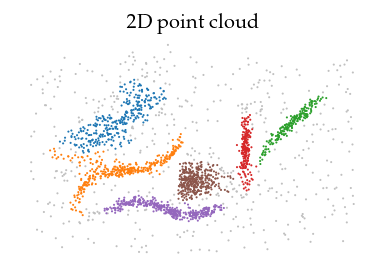

In [13]:
sized_fig(0.33, 0.7)
mask = labels == -1
plot_kwargs = dict(s=1, cmap="tab10", vmax=9, vmin=0, edgecolors="none")
plt.scatter(*data[mask].T, color="silver", s=1, edgecolors="none")
plt.scatter(*data[~mask].T, c=labels[~mask] % 10, **plot_kwargs)
plt.axis("off")
plt.suptitle("2D point cloud", y=1, va="top")
plt.subplots_adjust(0, 0, 1, 0.92)
plt.savefig("images/plscan_density_smoothing_data.pdf", pad_inches=0)
plt.show()

## Leaf tree explainer


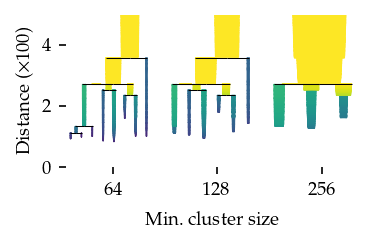

In [14]:
sized_fig(0.32, 0.66)

yticks = [0, 0.02, 0.04]
symbol = "m_{\\rm c}"
mcs = [64, 128, 256]
for i, mc in enumerate(mcs):
    plt.subplot(1, 3, i + 1)
    c3 = PLSCAN(min_samples=5, min_cluster_size=mc).fit(data)
    c3.condensed_tree_.plot(colorbar=False, leaf_separation=1)
    plt.ylim(0, 0.05)
    if i == 0:
        plt.ylabel("Distance ($\\times 100$)")
        plt.yticks(yticks)
        plt.gca().set_yticklabels([f"${int(y*100)}$" for y in yticks])
    else:
        plt.ylabel("")
        plt.yticks([])
    plt.xticks(np.diff(plt.xlim()) / 2)
    plt.gca().set_xticklabels([f"${mc}$"])
plt.text(
    (1 - 0.17) / 2 + 0.17,
    0.04,
    "Min.~cluster size",
    horizontalalignment="center",
    verticalalignment="center",
    transform=plt.gcf().transFigure,
    fontsize=fontsize["small"],
)
# plt.suptitle("Condensed trees", y=1)
plt.subplots_adjust(0.16, 0.28, 1, 0.95)
plt.savefig("images/plscan_condensed_trees.pdf", pad_inches=0)
plt.show()

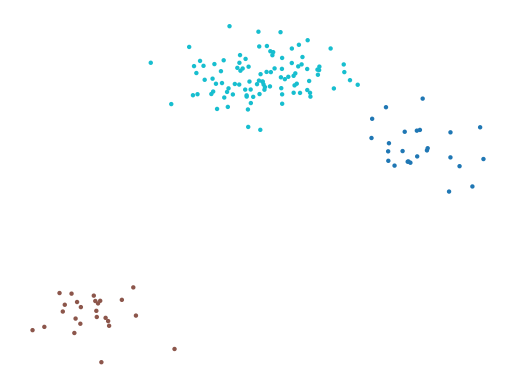

In [15]:
from sklearn.datasets import make_blobs

X1, y1 = make_blobs(50, centers=2, random_state=1)
X2, y2 = make_blobs(100, centers=1, random_state=5)
X = np.vstack((X1, X2))
y = np.hstack((y1, y2 + y1.max() + 1))

c = PLSCAN(min_samples=10).fit(X)
plt.scatter(*X.T, c=y, s=10, cmap="tab10", edgecolors="none")
plt.axis("off")
plt.show()

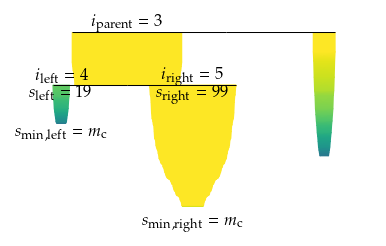

In [16]:
sized_fig(0.32, 0.66)
leaf_separation = 3
t = c.condensed_tree_
sizes = c._condensed_tree.child_size[c._condensed_tree.cluster_rows]
xcoords = t._x_coords(t._leaf_tree.parent) * leaf_separation
t.plot(y="density", leaf_separation=leaf_separation, colorbar=False)
plt.yticks([])
plt.ylabel("")
plt.ylim(0.6, None)
plt.text(
    xcoords[3],
    np.exp(-t._leaf_tree.max_distance[3]),
    r"$i_{\rm parent} = 3$",
    ha="center",
    va="bottom",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[4],
    np.exp(-t._leaf_tree.max_distance[4]),
    r"$i_{\rm left} = 4$",
    ha="center",
    va="bottom",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[5],
    np.exp(-t._leaf_tree.max_distance[5]),
    r"$i_{\rm right} = 5$",
    ha="center",
    va="bottom",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[4],
    np.exp(-t._leaf_tree.min_distance[4]),
    r"$s_{\rm min,left} = m_{\rm c}$",
    ha="center",
    va="top",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[5],
    np.exp(-t._leaf_tree.min_distance[5]),
    r"$s_{\rm min,right} = m_{\rm c}$",
    ha="center",
    va="top",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[4],
    np.exp(-t._leaf_tree.max_distance[4]),
    r"$s_{\rm left} = " + f"{sizes[2]:.0f}$",
    ha="center",
    va="top",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[5],
    np.exp(-t._leaf_tree.max_distance[5]),
    r"$s_{\rm right} = " + f"{sizes[3]:.0f}$",
    ha="center",
    va="top",
    fontsize=fontsize["footnote"],
)
plt.subplots_adjust(-0.09, 0.13, 0.88, 0.9)
plt.savefig("images/leaf_tree_explainer_1.pdf", pad_inches=0)
plt.show()

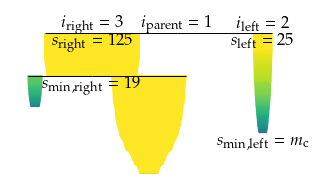

In [17]:
sized_fig(0.32, 0.66)
t.plot(y="density", leaf_separation=leaf_separation, colorbar=False)
plt.yticks([])
plt.ylabel("")
plt.ylim(0.6, None)
plt.text(
    xcoords[1],
    np.exp(-t._leaf_tree.max_distance[1]),
    r"$i_{\rm parent} = 1$",
    ha="center",
    va="bottom",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[2],
    np.exp(-t._leaf_tree.max_distance[2]),
    r"$i_{\rm left} = 2$",
    ha="center",
    va="bottom",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[3],
    np.exp(-t._leaf_tree.max_distance[3]),
    r"$i_{\rm right} = 3$",
    ha="center",
    va="bottom",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[2],
    np.exp(-t._leaf_tree.min_distance[2]),
    r"$s_{\rm min,left} = m_{\rm c}$",
    ha="center",
    va="top",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[3],
    np.exp(-t._leaf_tree.min_distance[3]),
    r"$s_{\rm min,right} = 19$",
    ha="center",
    va="top",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[2],
    np.exp(-t._leaf_tree.max_distance[2]),
    r"$s_{\rm left} = " + f"{sizes[0]:.0f}$",
    ha="center",
    va="top",
    fontsize=fontsize["footnote"],
)
plt.text(
    xcoords[3],
    np.exp(-t._leaf_tree.max_distance[3]),
    r"$s_{\rm right} = " + f"{sizes[1]:.0f}$",
    ha="center",
    va="top",
    fontsize=fontsize["footnote"],
)
plt.subplots_adjust(0.16, 0.28, 1, 0.9)
plt.savefig("images/leaf_tree_explainer_2.pdf", pad_inches=0)
plt.show()

In [18]:
for r in c._condensed_tree.cluster_rows:
    print(
        c._condensed_tree.parent[r] - X.shape[0],
        c._condensed_tree.child[r] - X.shape[0],
        c._condensed_tree.child_size[r],
        c._condensed_tree.distance[r],
    )

1 2 25.0 8.137202
1 3 125.0 8.137202
3 4 19.0 1.7068086
3 5 99.0 1.7068086


In [19]:
for parent, min_dist, max_dist, min_size, max_size in zip(*c._leaf_tree):
    print(parent, min_dist, max_dist, min_size, max_size)

0 0.0 8.137202 25.0 150.0
0 8.137202 8.137202 25.0 25.0
1 0.85816634 8.137202 10.0 25.0
1 1.7068086 8.137202 19.0 25.0
3 1.1621532 1.7068086 10.0 19.0
3 0.47154778 1.7068086 10.0 19.0


## Computational costs


In [36]:
benchmark_results = pd.read_parquet("data/generated/benchmark_time.parquet")
timeout = 20
alg_names = [
    "plscan (kd-tree)",
    "plscan (ball-tree)",
    "fast_hdbscan",
    "hdbscan",
    "kmeans",
]

In [37]:
def to_display_name(input):
    if input == "kmeans":
        return "$k$-Means++"
    if input == "hdbscan":
        return "HDBSCAN*"
    if input == "fast_hdbscan":
        return "HDBSCAN* (fast)"
    if input == "plscan (kd-tree)":
        return "PLSCAN ($k$D-tree)"
    if input == "plscan (ball-tree)":
        return "PLSCAN (ball-tree)"
    return input

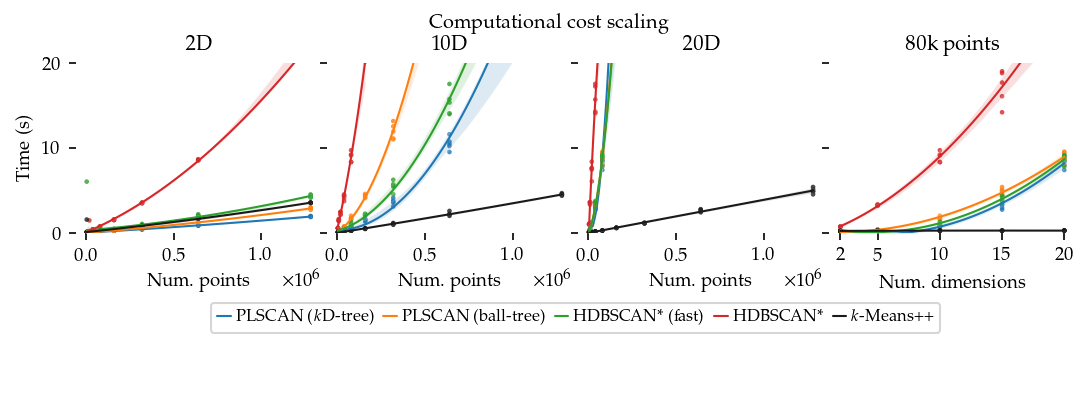

In [38]:
legend_ids = [[], [], [0, 1, 2], [3, 4]]
palette = ["C0", "C1", "C2", "C3", "k"]
ticks = [0, 10, 20]

sized_fig(1, 1.2 / 4)
for i, d in enumerate([2, 10, 20]):
    plt.subplot(2, 4, i + 1)
    plt.title(f"{d}D")
    for j, name in enumerate(alg_names):
        sns.regplot(
            benchmark_results.query(f"n_features == {d} & algorithm == '{name}'"),
            x="n_samples",
            y="elapsed_time",
            color=palette[j],
            order=2,
            line_kws={"linewidth": 1},
            scatter_kws={"s": 5, "edgecolor": "none"},
        )
    plt.xlabel("Num.~points")
    plt.ylim(0, timeout)
    plt.yticks(ticks)
    if i == 0:
        plt.ylabel("Time (s)")
    else:
        plt.ylabel("")
        plt.gca().set_yticklabels(["" for t in ticks])
plt.subplot(2, 4, 4)
for i, name in enumerate(alg_names):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sns.regplot(
            benchmark_results.query(f"algorithm == '{name}' & n_samples == 80000"),
            x="n_features",
            y="elapsed_time",
            color=palette[i],
            order=2,
            line_kws={"linewidth": 1},
            scatter_kws={"s": 5, "edgecolor": "none"},
        )

plt.xticks([2, 5, 10, 15, 20])
plt.ylim(0, timeout)
plt.yticks(ticks)
plt.gca().set_yticklabels(["" for t in ticks])
plt.ylabel("")
plt.xlabel("Num.~dimensions")
plt.title("80k points")
plt.suptitle("Computational cost scaling", y=1)

plt.subplot(2, 1, 2)
plt.legend(
    handles=[
        plt.Line2D([0], [0], color=p, lw=1, label=to_display_name(n))
        for p, n in zip(palette, alg_names)
    ],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.36),
    handlelength=0.8,
    columnspacing=0.6,
    handletextpad=0.3,
    ncol=len(alg_names),
)
plt.axis("off")

plt.subplots_adjust(0.06, -0.2, 0.99, 0.85, hspace=0, wspace=0.02)
plt.savefig("images/benchmark_time.pdf", pad_inches=0)
plt.show()

## Parameter sensitivity

In [6]:
df = pd.read_parquet("data/generated/benchmark_sensitivity.parquet")
deltas = np.load("data/generated/benchmark_sensitivity_deltas.npy")
min_sample_sizes = np.load("data/generated/benchmark_sensitivity_min_sizes.npy")
new_values = np.load("data/generated/benchmark_sensitivity_perturbed_values.npy")

In [7]:
sensitivity_records = []
for data_set, alg_id in product(df.data_set.unique(), df.alg_id.unique()):
    sub_df = df.query(f"data_set == '{data_set}' & alg_id == '{alg_id}'")
    vals = defaultdict(lambda: np.nan, {k: v for k, v in zip(sub_df.k, sub_df.ari)})
    lookup_fun = np.vectorize(lambda x: vals[x])
    initial_val = lookup_fun(min_sample_sizes)[np.newaxis, :, :]
    perturbed_val = lookup_fun(new_values)
    with np.errstate(divide="ignore", invalid="ignore"):
        diff = np.abs((perturbed_val - initial_val) / (perturbed_val + initial_val))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        sensitivity = np.nanmean(diff, axis=(1, 2))
    for delta, sensitivity in zip(deltas[:, 0], sensitivity):
        sensitivity_records.append(
            {
                "data_set": data_set,
                "alg_id": alg_id,
                "perturbation": delta,
                "sensitivity": sensitivity,
            }
        )

# Convert to pandas
df_sens = pd.DataFrame.from_records(sensitivity_records)
df_sens.head()

,data_set,alg_id,perturbation,sensitivity
0,articles_1442_5,plscan_size,2,0.013788
1,articles_1442_5,plscan_size,5,0.031861
2,articles_1442_5,plscan_size,10,0.057931
3,articles_1442_5,plscan_distance,2,0.021419
4,articles_1442_5,plscan_distance,5,0.043571


In [8]:
def to_display_name(input):
    parts = input.split("_")
    name = parts[0].upper()
    if name == "KMEANS":
        if parts[1] == "random":
            return "$k$-Means"
        if parts[1] == "++":
            return "$k$-Means++"
    if name == "HDBSCAN":
        name = "HDBSCAN*"
        return f"{name} ({' '.join([p.replace('eom', 'EOM') for p in parts[1:]])})"
    if name == "PLSCAN":
        return f"{name}"
    return input


def dataset_name(input):
    names = dict(
        iris="Iris",
        mnist="MNIST",
        fashion_mnist="Fashion-MNIST",
        articles_1442_5="Articles-1442-5",
        articles_1442_80="Articles-1442-80",
        audioset="Audioset~(music)",
        authorship="Authorship",
        cardiotocography="CTG",
        cell_cycle_237="CellCycle-237",
        cifar_10="CIFAR-10",
        ecoli="E.~coli",
        elegans="C.~elegans",
        mfeat_factors="Mfeat-Factors",
        mfeat_karhunen="Mfeat-Karhunen",
        newsgroups="20 Newsgroups",
        semeion="Semeion Digits",
        yeast_galactose="YeastGalactose",
    )
    return names.get(input, input)


def short_display_name(input):
    res = to_display_name(input)
    return res.replace(" (", "\n").replace(")", "")


alg_ids = ["hdbscan_eom", "hdbscan_leaf", "plscan_size"]
palette = plt.get_cmap("tab10").colors

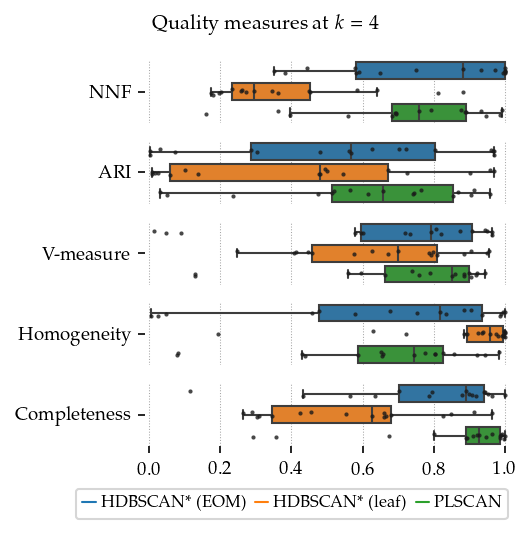

In [9]:
measures = {
    "non_noise_fraction": "NNF",
    "ari": "ARI",
    "v_measure": "V-measure",
    "homogeneity": "Homogeneity",
    "completeness": "Completeness",
}

fig = sized_fig(0.5, 1)
n_measures = len(measures)
sub_df = df.query("k==4 and alg_id in @alg_ids")

for i, measure in enumerate(measures.keys(), 1):
    plt.subplot(n_measures, 1, i)
    plt.grid(axis="x", color="gray", linestyle=":", linewidth=0.5, alpha=0.7)
    sns.boxplot(
        data=sub_df,
        x=measure,
        y="alg_id",
        hue="alg_id",
        order=alg_ids,
        hue_order=alg_ids,
        palette=palette,
        legend=False,
        fliersize=0,
        linewidth=1,
        formatter=to_display_name,
    )
    sns.stripplot(
        data=sub_df,
        x=measure,
        y="alg_id",
        order=alg_ids,
        legend=False,
        color="k",
        size=2,
        alpha=0.8,
        jitter=0.15,
        formatter=to_display_name,
    )
    plt.ylabel("")
    plt.xlabel("")
    plt.xlim(-0.01, 1.01)
    if i < len(measures):
        plt.gca().set_xticklabels([])
        plt.gca().tick_params(axis="x", which="both", length=0)
    plt.yticks([1])
    plt.gca().set_yticklabels([measures[measure]])

plt.legend(
    handles=[
        plt.Line2D([0], [0], color=palette[j], lw=1, label=to_display_name(n))
        for j, n in enumerate(alg_ids)
    ],
    loc="upper right",
    bbox_to_anchor=(1.02, -0.55),
    handlelength=0.8,
    columnspacing=0.6,
    handletextpad=0.3,
    ncol=len(alg_ids),
)

plt.suptitle("Quality measures at $k=4$")
plt.tight_layout()
plt.savefig("images/parameter_sensitivity.pdf", pad_inches=0)
plt.show()

In [11]:
(
    sub_df.drop(columns=["data_set", "alg_config"])
    .groupby("alg_id")
    .agg(np.median)
    .round(2)
)

,ari,homogeneity,completeness,v_measure,non_noise_fraction,compute_time,k
alg_id,,,,,,,
hdbscan_eom,0.57,0.82,0.89,0.79,0.88,0.32,4.0
hdbscan_leaf,0.48,0.96,0.63,0.70,0.29,0.34,4.0
plscan_size,0.66,0.74,0.93,0.85,0.76,0.06,4.0


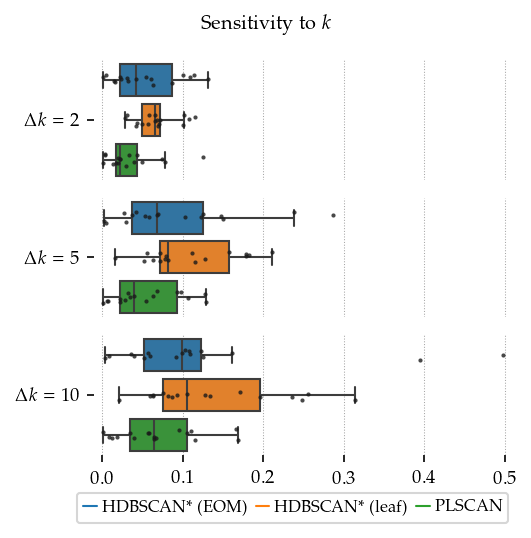

In [12]:
perturbations = {
    2: "$\\Delta k = 2$",
    5: "$\\Delta k = 5$",
    10: "$\\Delta k = 10$",
}

fig = sized_fig(0.5, 1)
n_perturbations = len(perturbations)
sub_df = df_sens.query("alg_id in @alg_ids").pivot(
    index=["data_set", "alg_id"], columns="perturbation", values="sensitivity"
).reset_index()
for i, perturbation in enumerate(perturbations, 1):
    plt.subplot(n_perturbations, 1, i)
    plt.grid(axis="x", color="gray", linestyle=":", linewidth=0.5, alpha=0.7)
    sns.boxplot(
        data=sub_df,
        x=perturbation,
        y="alg_id",
        hue="alg_id",
        order=alg_ids,
        hue_order=alg_ids,
        palette=palette,
        legend=False,
        fliersize=0,
        linewidth=1,
        formatter=to_display_name,
    )
    sns.stripplot(
        data=sub_df,
        x=perturbation,
        y="alg_id",
        order=alg_ids,
        legend=False,
        color="k",
        size=2,
        alpha=0.8,
        jitter=0.15,
        formatter=to_display_name,
    )
    plt.ylabel("")
    plt.xlabel("")
    plt.xlim(-0.01, 0.51)
    if i < len(perturbations):
        plt.gca().set_xticklabels([])
        plt.gca().tick_params(axis="x", which="both", length=0)
    plt.yticks([1])
    plt.gca().set_yticklabels([perturbations[perturbation]])

plt.legend(
    handles=[
        plt.Line2D([0], [0], color=palette[j], lw=1, label=to_display_name(n))
        for j, n in enumerate(alg_ids)
    ],
    loc="upper right",
    bbox_to_anchor=(1.01, -0.25),
    handlelength=0.8,
    columnspacing=0.6,
    handletextpad=0.3,
    ncol=len(alg_ids),
)

plt.suptitle("Sensitivity to $k$")
plt.tight_layout()
plt.savefig("images/parameter_sensitivity_perturbations.pdf", pad_inches=0)
plt.show()

In [13]:
(
    sub_df.drop(columns=["data_set"])
    .groupby("alg_id")
    .agg(np.median)
    .round(2)
)

perturbation,2,5,10
alg_id,,,
hdbscan_eom,0.04,0.07,0.10
hdbscan_leaf,0.07,0.08,0.11
plscan_size,0.02,0.04,0.06


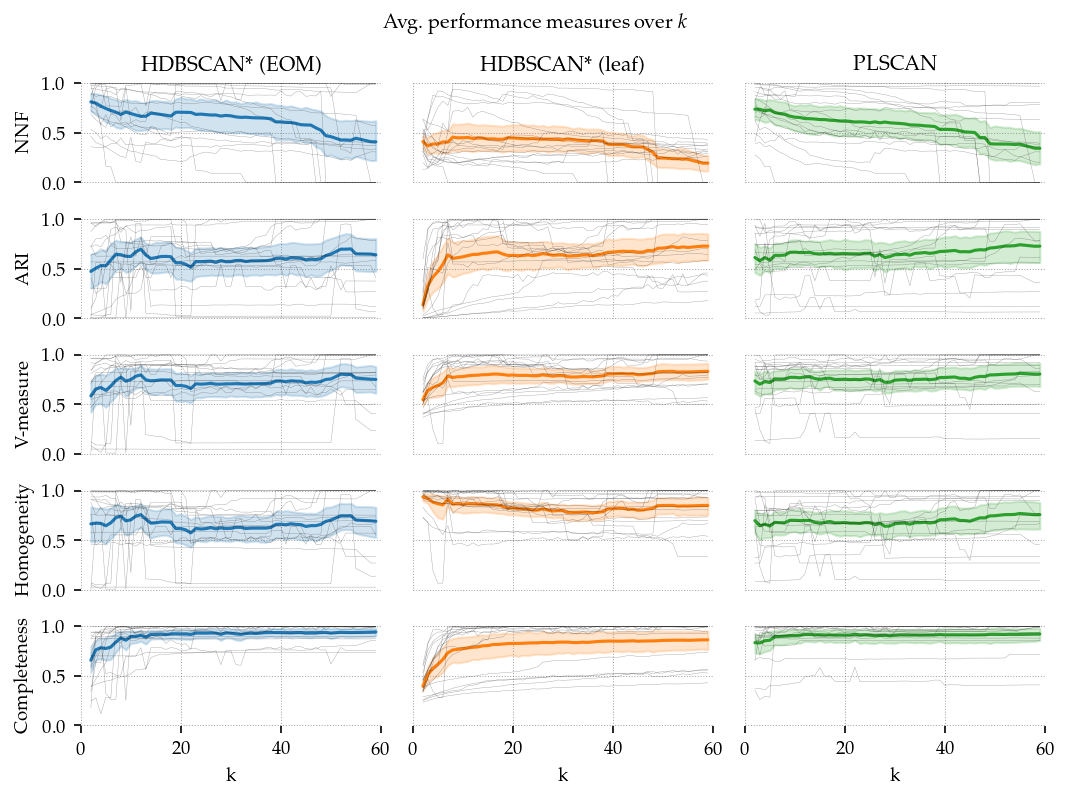

In [55]:
fig = sized_fig(1, 0.75)


for i, alg_id in enumerate(alg_ids, 1):
    sub = df.query("alg_id == @alg_id")
    for j, (measure, label) in enumerate(measures.items()):
        plt.subplot(len(measures), len(alg_ids), j * len(alg_ids) + i)
        plt.grid(axis="both", color="gray", linestyle=":", linewidth=0.5, alpha=0.7)
        if j == 0:
            plt.title(to_display_name(alg_id))

        sns.lineplot(data=sub, x="k", y=measure, color=palette[i - 1])
        for dataset in sub["data_set"].unique():
            sns.lineplot(
                data=sub.query("data_set == @dataset"),
                x="k",
                y=measure,
                color="k",
                linewidth=0.2,
                alpha=0.4,
            )

        plt.xlabel("k" if j == len(measures) - 1 else "")
        plt.ylabel(label if i == 1 else "")

        plt.xlim(-0.01, 60.01)
        plt.ylim(-0.01, 1.01)
        xticks = [0, 20, 40, 60]
        yticks = [0, 0.5, 1.0]

        plt.xticks(xticks)
        plt.yticks(yticks)
        if j < len(measures) - 1:
            plt.gca().set_xticklabels([])
            plt.gca().tick_params(axis="x", which="both", length=0)
        if i > 1:
            plt.gca().set_yticklabels([])
            plt.gca().tick_params(axis="y", which="both", length=0)

plt.suptitle("Avg.~performance measures over $k$")
plt.tight_layout()
plt.savefig("images/parameter_sensitivity_k.pdf", pad_inches=0)
plt.show()

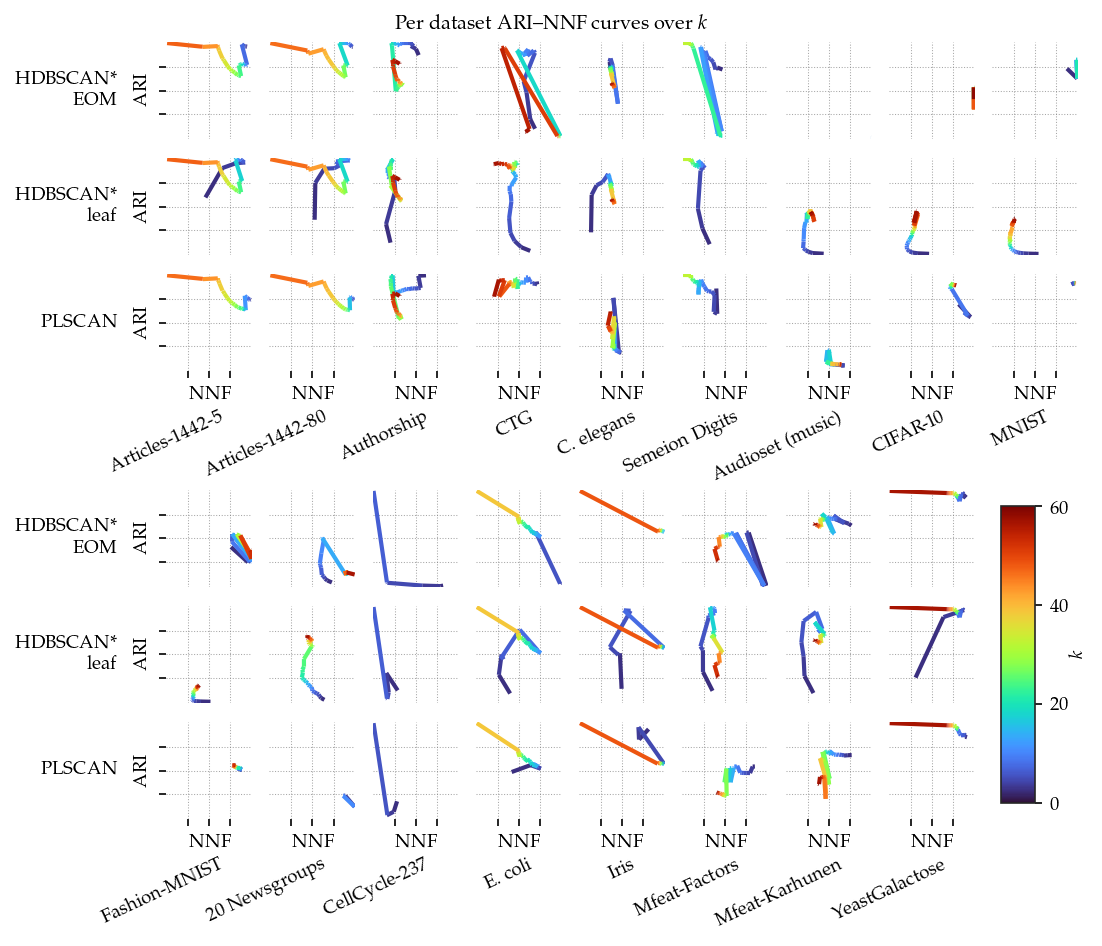

In [56]:
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection

cmap = plt.get_cmap("turbo")
norm = plt.Normalize(0, 60)
datasets = df.data_set.unique()


def draw_snakes(gs, datasets):
    for r, alg_id in enumerate(alg_ids):
        for c, data_set in enumerate(datasets):
            ax = fig.add_subplot(gs[r, c])
            ax.grid(axis="both", color="gray", linestyle=":", linewidth=0.5, alpha=0.7)

            if r == len(alg_ids) - 1:
                ax.set_xlabel("NNF", labelpad=0)
                ax.text(
                    0.7,
                    -0.4,
                    dataset_name(data_set),
                    ha="right",
                    va="top",
                    fontsize=fontsize["small"],
                    rotation=25,
                )
            else:
                ax.tick_params(axis="x", which="both", length=0)
            if c > 0:
                ax.tick_params(axis="y", which="both", length=0)
            else:
                ax.set_ylabel("ARI", labelpad=0)
                ax.text(
                    -0.6,
                    0.5,
                    short_display_name(alg_id),
                    ha="right",
                    va="center",
                    fontsize=fontsize["small"],
                )
            ax.set_xlim(-0.01, 1.01)
            ax.set_ylim(-0.01, 1.01)
            ax.set_xticks([0.25, 0.5, 0.75])
            ax.set_yticks([0.25, 0.5, 0.75])
            ax.set_xticklabels([])
            ax.set_yticklabels([])

            segments = df.query(
                f"alg_id == '{alg_id}' & data_set == '{data_set}'"
            ).sort_values("k")
            ks = segments.k.values
            xy = segments[["non_noise_fraction", "ari"]].values
            segs = [xy[i : i + 2] for i in range(len(xy) - 1)]
            col = LineCollection(segs, linewidth=2, cmap=cmap, norm=norm)
            col.set_array(
                (ks[:-1] + ks[1:]) / 2
            )  # colour each segment by its midpoint k
            ax.add_collection(col)


fig = sized_fig(1, 0.85)
gs_top = GridSpec(
    3, 9, figure=fig, top=0.97, bottom=0.49 + 0.12, left=0.142, right=0.99
)
gs_bot = GridSpec(3, 9, figure=fig, top=0.48, bottom=0.0 + 0.12, left=0.142, right=0.99)

draw_snakes(gs_top, datasets[:9])
draw_snakes(gs_bot, datasets[9:])

# Colorbar: use the last column of the bottom panel as a container, then
# inset a narrower axes within it so the bar does not span the full column width.
ax_cbar_host = fig.add_subplot(gs_bot[:, -1])
ax_cbar_host.axis("off")
cax = ax_cbar_host.inset_axes([0.1, 0.05, 0.4, 0.9])  # centered, 40 % of column width
cb = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax)
cb.set_label("$k$", labelpad=0)
cb.set_ticks([0, 20, 40, 60])
plt.suptitle("Per dataset ARI--NNF curves over $k$", y=1)
plt.savefig("images/parameter_sensitivity_grid.pdf", pad_inches=0)
plt.show()

## Clustering Stability

In [14]:
alg_ids = [*alg_ids, "kmeans_random", "kmeans_++"]
stability_df = pd.read_parquet("data/generated/clustering_stability_results.parquet")

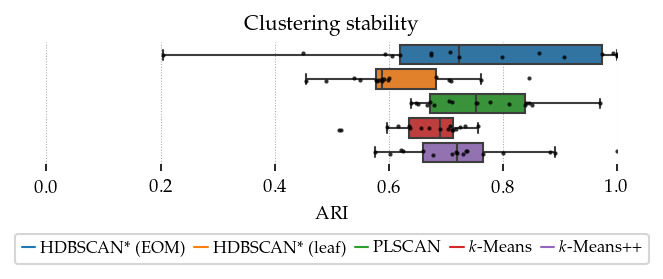

In [15]:
plot_df = (
    stability_df.query("alg_id in @alg_ids")
    .groupby(["dataset", "alg_id"])["ari"]
    .agg("mean")
    .reset_index()
)
sized_fig(0.65, 0.4)
plt.grid(axis="x", color="gray", linestyle=":", linewidth=0.5, alpha=0.7)
sns.boxplot(
    data=plot_df,
    x="ari",
    y="alg_id",
    hue="alg_id",
    hue_order=alg_ids,
    order=alg_ids,
    palette=palette,
    legend=False,
    fliersize=0,
    formatter=short_display_name,
)
sns.stripplot(
    data=plot_df,
    x="ari",
    y="alg_id",
    order=alg_ids,
    legend=False,
    color="black",
    size=2,
    alpha=0.8,
    formatter=short_display_name,
)
plt.ylabel("")
plt.xlim(0, 1)
plt.xlabel("ARI")
plt.yticks([])

plt.legend(
    handles=[
        plt.Line2D([0], [0], color=palette[j], lw=1, label=to_display_name(n))
        for j, n in enumerate(alg_ids)
    ],
    loc="upper center",
    bbox_to_anchor=(.5, -0.5),
    handlelength=0.8,
    columnspacing=0.6,
    handletextpad=0.3,
    ncol=len(alg_ids),
)
plt.title("Clustering stability")
plt.tight_layout()
plt.subplots_adjust(bottom=0.4)
plt.savefig("images/clustering_stability.pdf", pad_inches=0)
plt.show()

In [119]:
plot_df.groupby("alg_id")["ari"].agg("median").round(2)

alg_id
hdbscan_eom      0.72
hdbscan_leaf     0.59
kmeans_++        0.72
kmeans_random    0.69
plscan_size      0.75
Name: ari, dtype: float64